# 05. 시계열 분석

### 배경 및 설치

In [3]:
#윈도우 유저는 visual C++ build Tool먼저 설치 필요

In [5]:
from pandas_datareader import data
from prophet import Prophet

---

## def의 기초

In [5]:
def test_df(a,b):
    return a + b #리턴으로 저장해야 다른 곳에서도 변수로 활용이 가능하다

In [8]:
c = test_df(3,4)
c

7

In [10]:
5+c

12

In [18]:
a = 1 #전역변수

def edit_a(i):
    #지역변수
    global a
    a = i 

In [20]:
edit_a(2)

In [22]:
a

2

$$ y=asin(2\pi ft + t_0)+b $$

In [6]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [30]:
def plotSineWave(**kwargs):
    """
    plot sine wave
    y = a sin(2 pi f t +t_0) +b
    """
    
    endTime = kwargs.get("endTime",1)
    sampleTime = kwargs.get("sampleTime",0.01)
    amp = kwargs.get("amp",1)
    freq = kwargs.get("freq",1)
    startTime = kwargs.get("startTime",1)
    bias = kwargs.get("bias",1)
    figsize = (12,6)
    
    time = np.arange(startTime, endTime, sampleTime)
    result = amp*np.sin(2*np.pi*freq*time+startTime)+bias
    
    plt.figure(figsize=(12,6))
    plt.plot(time,result)
    plt.grid(True)
    plt.xlabel("Time시간이란다")
    plt.ylabel("sin")
    plt.title(str(amp)+"*sin(2*pi" + str(freq) + "*t+" + str(startTime)+ ")"+str(bias))
    plt.show()

C:\Users\shchoi\anaconda3\envs\ds_study\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shchoi\anaconda3\envs\ds_study\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shchoi\anaconda3\envs\ds_study\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shchoi\anaconda3\envs\ds_study\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46976 (\N{HANGUL SYLLABLE RAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shchoi\anaconda3\envs\ds_study\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from current fo

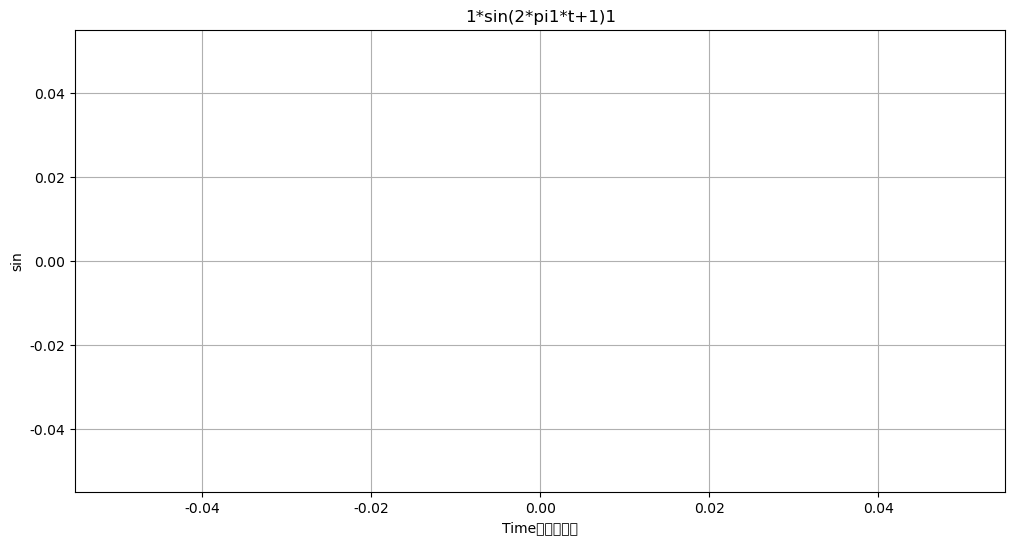

In [31]:
# plotSineWave(2,1,10,0.01,0.5,0)
plotSineWave()

Hello world
This is test graph!


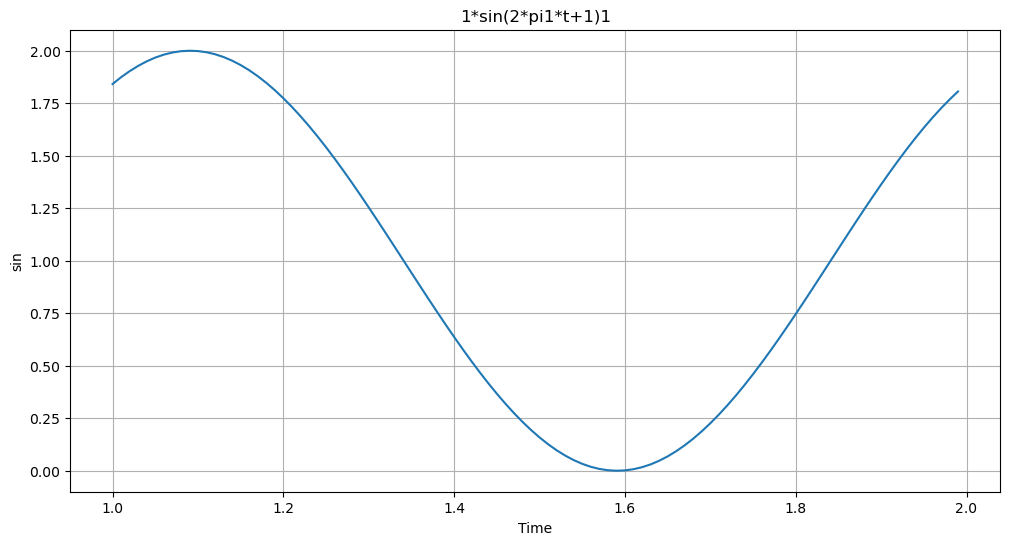

In [9]:
if __name__ == '__main__':
    print("Hello world")
    print("This is test graph!")
    plotSineWave(amp=1, endTime=2)


## 내가 만든 함수 import
- drawSineWave.py

In [7]:
%%writefile ./drawSinewave.py

import numpy as np
import matplotlib as plt

Overwriting ./drawSinewave.py


In [8]:
%%writefile ./set_matplotlib_hangul.py

import platform
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# path = 'C:/Windows/Fonts/malgun.ttf'

# if platform.system() == "Darwin":
#     print("MAC")
# elif platform.system() == "Windows":    
#     font_name = font_manager.FontProperties(fname=path).get_name()
#     print('한글 굿')
#     rc('font', family=font_name)
# else:
#     print("sorry")
    
# plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt
 
# 한글 폰트 사용을 위해서 세팅
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/NGULIM.TTF"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)

Overwriting ./set_matplotlib_hangul.py


In [9]:
import set_matplotlib_hangul

Text(0.5, 1.0, '한글')

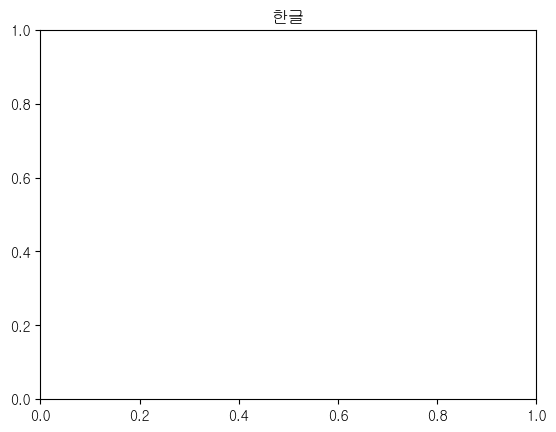

In [10]:
plt.title('한글')

## FBprophet 기초

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [49]:
time = np.linspace(0,1,365*2)
result = np.sin(2*np.pi*12*time)
ds = pd.date_range("2018-01-01", periods=365*2,freq='D')
df = pd.DataFrame({"ds":ds, 'y':result})
df.head()

,ds,y
0,2018-01-01,0.000000
1,2018-01-02,0.103243
2,2018-01-03,0.205382
3,2018-01-04,0.305326
4,2018-01-05,0.402007


<Axes: >

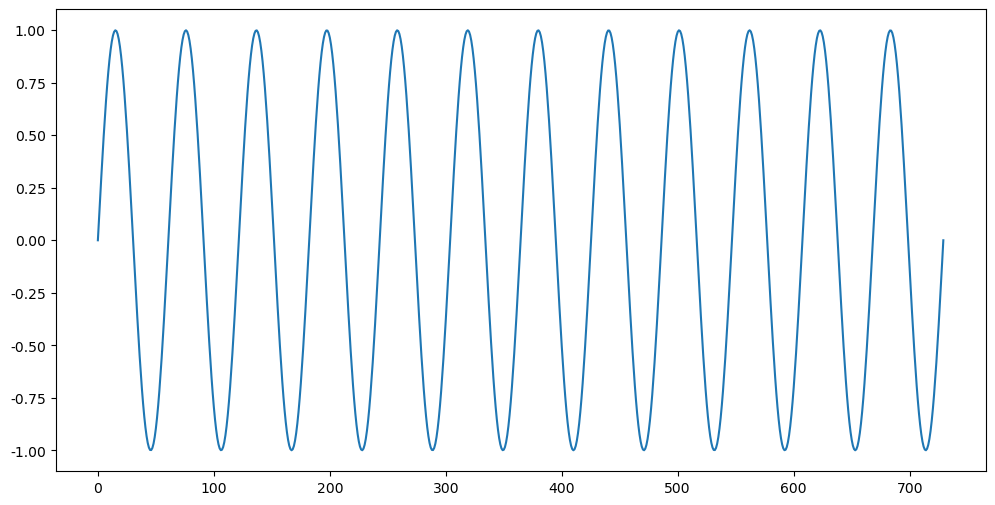

In [52]:
df['y'].plot(figsize=(12,6))

In [58]:
from prophet import Prophet

m = Prophet(yearly_seasonality=True, daily_seasonality=True)
m.fit(df);

00:42:49 - cmdstanpy - INFO - Chain [1] start processing
00:42:49 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

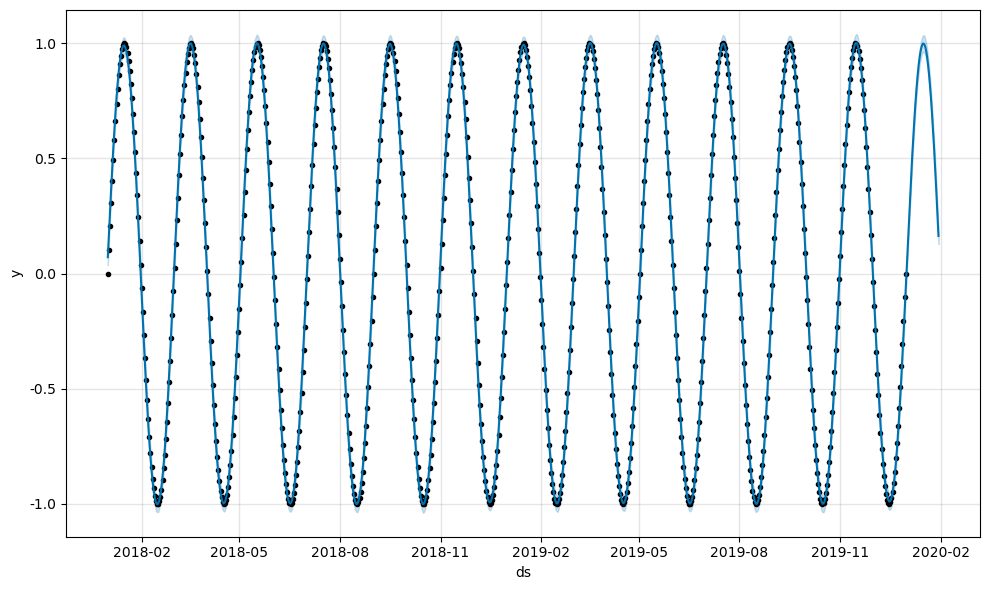

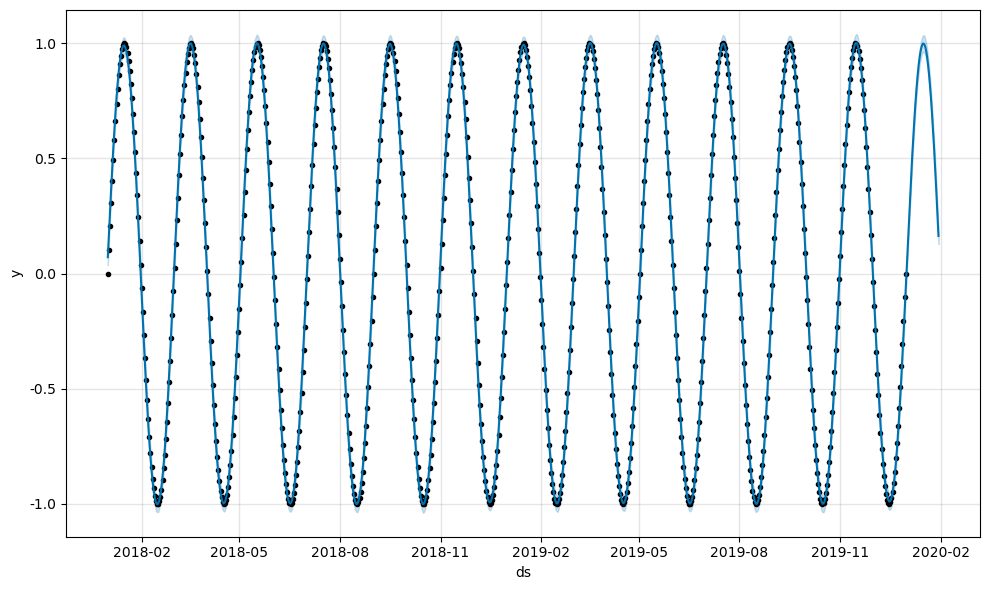

In [62]:
m.plot(forecast)

<Axes: >

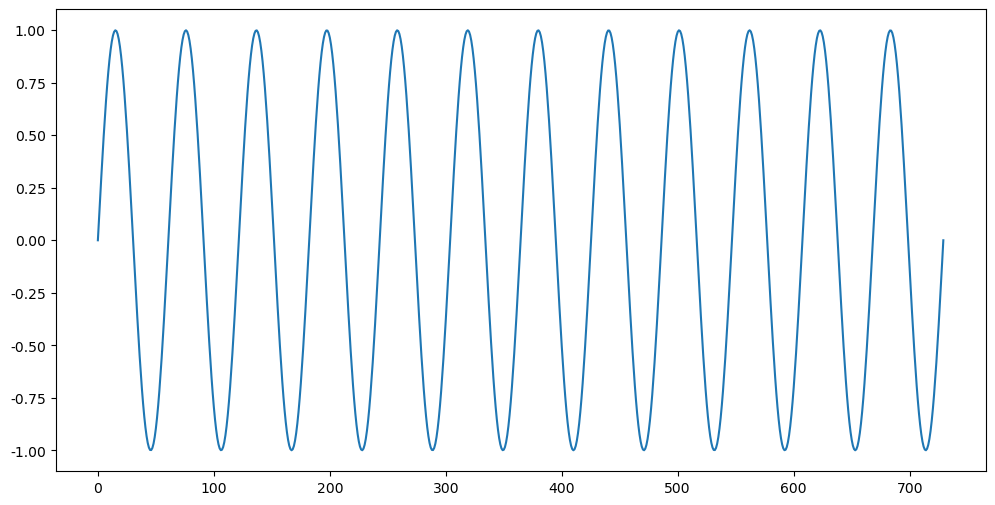

In [65]:
time = np.linspace(0,1,365*2)
result = np.sin(2*np.pi*12*time)
ds = pd.date_range("2018-01-01", periods=365*2,freq='D')
df = pd.DataFrame({"ds":ds, 'y':result})

df['y'].plot(figsize=(12,6))

## 3. 시계열 데이터 실전 이용

In [12]:
import pandas as pd
import pandas_datareader as web
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from datetime import datetime

%matplotlib inline

In [21]:
pinkwink_web = pd.read_csv("./data/05_PinkWink_Web_Traffic.csv", encoding = "utf-8", thousands=",",names=["date",'hit'], index_col=0)
pinkwink_web = pinkwink_web[pinkwink_web['hit'].notnull()]
pinkwink_web

,hit
date,
16. 7. 1.,766.0
16. 7. 2.,377.0
16. 7. 3.,427.0
16. 7. 4.,902.0
16. 7. 5.,850.0
...,...
17. 6. 26.,1309.0
17. 6. 27.,1436.0
17. 6. 28.,1387.0


<Axes: xlabel='date'>

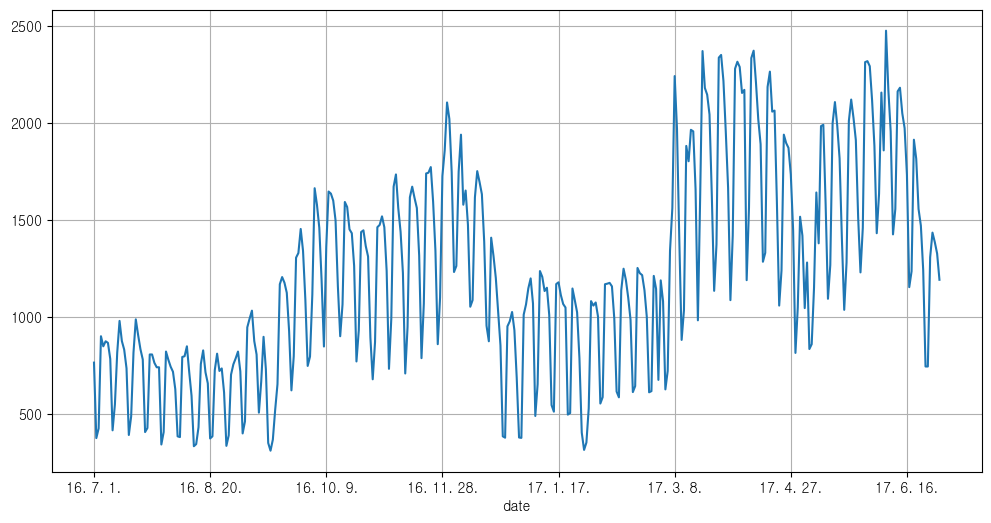

In [24]:
#전체 데이터 그려보기
pinkwink_web['hit'].plot(figsize=(12,6), grid=True)

In [30]:
# trend분석을 시각화하기위한 x축 값을 만들기
time = np.arange(0, len(pinkwink_web))
traffic = pinkwink_web['hit'].values
fx = np.linspace(0,time[-1], 1000)


In [31]:
# 에러를 계산할 함수
def error(f,x,y):
    return np.sqrt(np.mean(f(x)-y)**2)

In [34]:
fp1 = np.polyfit(time, traffic, 1)
f1 = np.poly1d(fp1)

fp2 = np.polyfit(time, traffic, 2)
f2 = np.poly1d(fp1)

fp3 = np.polyfit(time, traffic, 3)
f3 = np.poly1d(fp1)

fp15 = np.polyfit(time, traffic, 15)
f15 = np.poly1d(fp15)

In [37]:
print(error(f1,time,traffic))
print(error(f2,time,traffic))
print(error(f3,time,traffic))
print(error(f15,time,traffic))

1.7442364143590404e-13
1.7442364143590404e-13
1.7442364143590404e-13
1.1715531861090599e-06


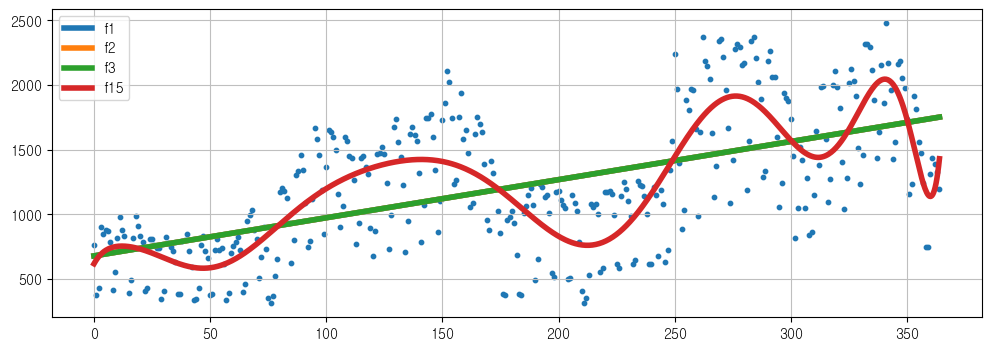

In [39]:
plt.figure(figsize=(12,4))
plt.scatter(time, traffic, s=10)
plt.plot(fx, f1(fx),lw=4,label="f1")
plt.plot(fx, f2(fx),lw=4,label="f2")
plt.plot(fx, f3(fx),lw=4,label="f3")
plt.plot(fx, f15(fx),lw=4,label="f15")

plt.grid(True,linestyle="-",color="0.75")
plt.legend(loc=2)
plt.show()


In [43]:
df = pd.DataFrame({"ds":pinkwink_web.index, 'y':pinkwink_web['hit']})
df.reset_index(inplace=True)
df["ds"] = pd.to_datetime(df['ds'], format="%y. %m. %d.")
del df['date']
df.head()

,ds,y
0,2016-07-01,766.0
1,2016-07-02,377.0
2,2016-07-03,427.0
3,2016-07-04,902.0
4,2016-07-05,850.0


In [46]:
m = Prophet(yearly_seasonality=True, daily_seasonality=True)
m.fit(df);

00:19:04 - cmdstanpy - INFO - Chain [1] start processing
00:19:05 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
#60일에 해당하는 데이터 예측
future = m.make_future_dataframe(periods=60)
future.tail()

,ds
420,2017-08-25
421,2017-08-26
422,2017-08-27
423,2017-08-28
424,2017-08-29


In [52]:
forecast = m.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
420,2017-08-25,921.853195,726.147612,1126.761180
421,2017-08-26,506.954908,305.517209,713.086162
422,2017-08-27,639.454293,434.254140,857.466412
423,2017-08-28,1191.944049,995.540464,1395.774918
424,2017-08-29,1227.806799,1000.733342,1420.509448


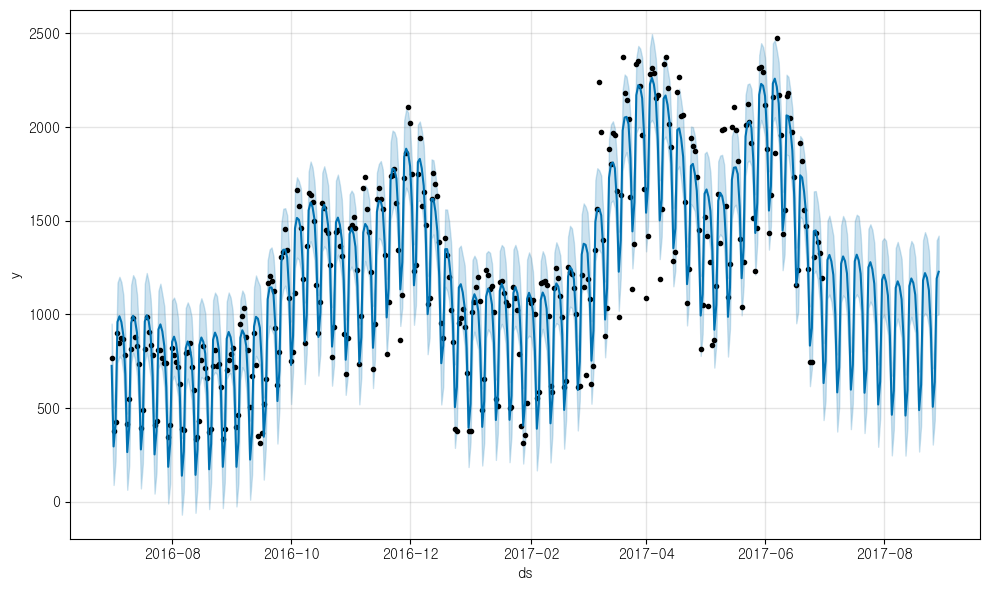

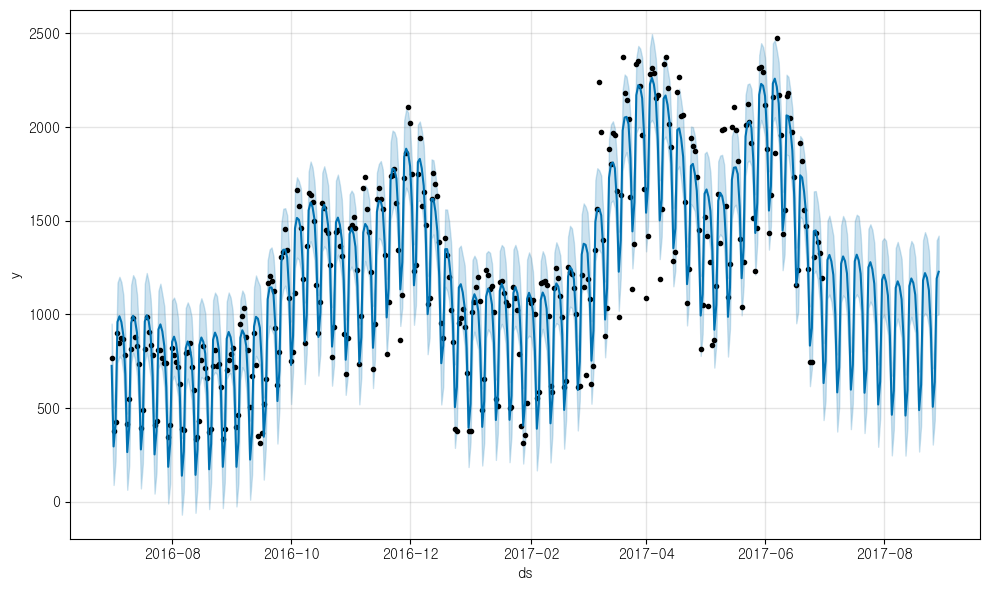

In [54]:
m.plot(forecast)

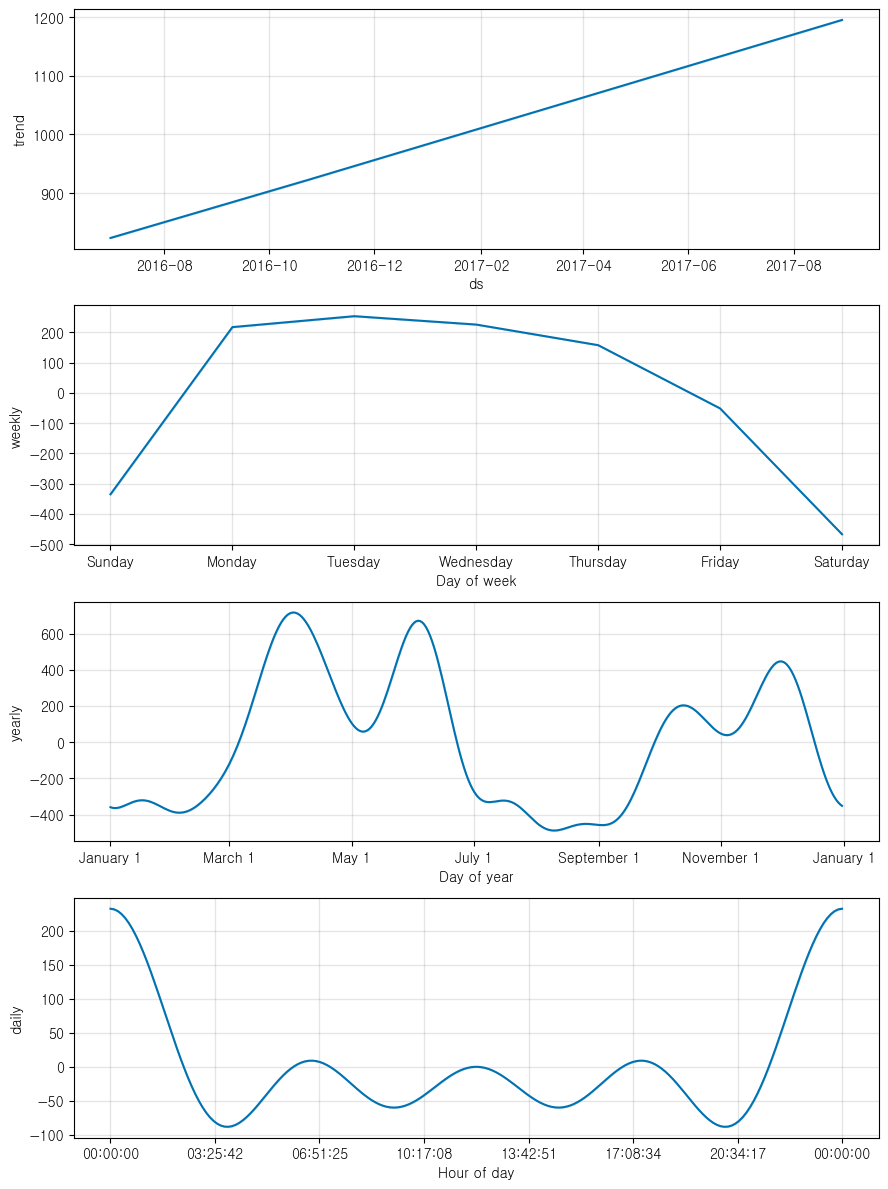

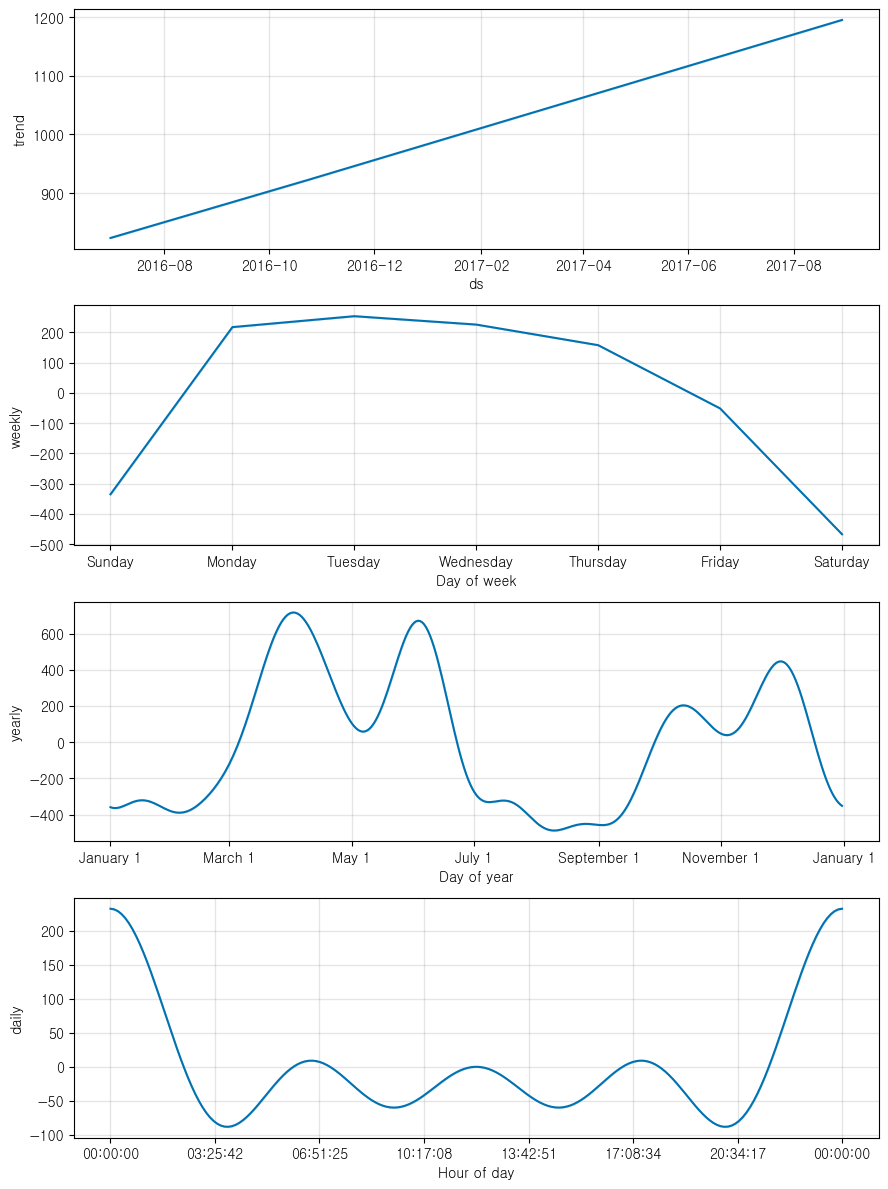

In [57]:
m.plot_components(forecast)